# Compare parameter estimation via stepwise BFGS with evofr

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import evofr as ef

from viral_variant_comp.simulate_count_data import create_count_data, convert_count_data_to_df, prepare_count_data_evofr
from viral_variant_comp.plotting import plot_viral_composition, plot_confidence_intervals, plot_heatmap, plot_confidence_intervals_deviation
from viral_variant_comp.estimate import calculate_viral_composition, evaluate_result, calculate_viral_composition_stepwise, reorder_variants, calculateHessian, calculate_cooccurence, calculate_frequencies

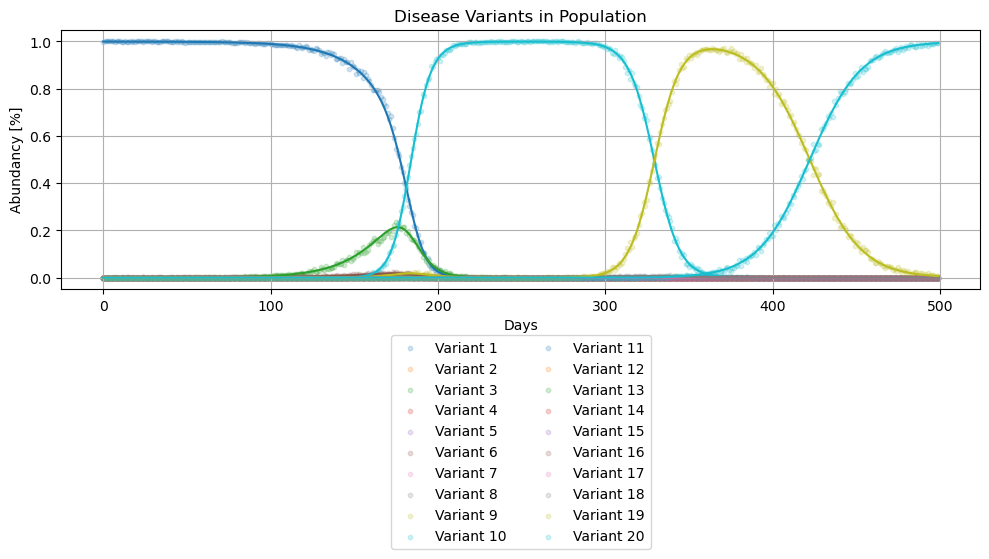

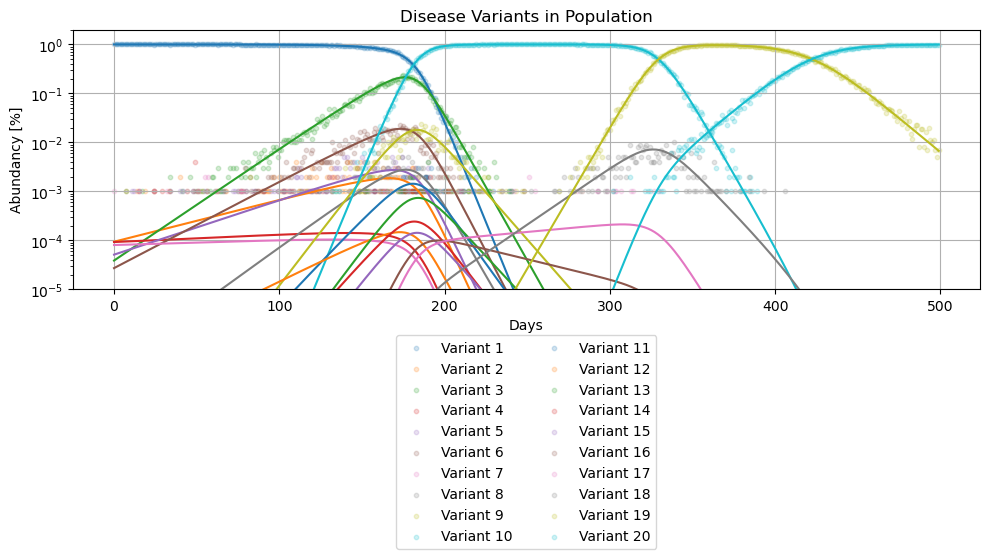

In [4]:
n_variants = 20
n_days = 500
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, n_days = n_days, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0)
plot_viral_composition(data['counts'], data['freq'], n_samples, logscale = False)
plot_viral_composition(data['counts'], data['freq'], n_samples, y_range = (1e-5, 2), logscale = True)

#np.savez('data/data_50var_1000days_1000samples.npz', **data)

## Use Evofr to estimate variant parameters
Evofr offers two main methods to estimate growth rate and log initial frequency from variant count data:
- MCMC sampling to approximate full posterior
    - implemented with inference method InferNUTS
- SVI (stochastic variational inference) to approximate MAP estimate
    - faster than MCMC
    - implemented with inference method InferMAP

In [5]:
counts_df = prepare_count_data_evofr(data['counts'])
counts_df.head()

,date,variant,sequences
0,2024-12-31,variant_0,999
1,2025-01-01,variant_0,1000
2,2025-01-02,variant_0,1000
3,2025-01-03,variant_0,1000
4,2025-01-04,variant_0,1000


In [6]:
def infer_parameters_forecast_evofr(counts_df):

    variant_names = [f"variant_{i+1}" for i in range(counts_df.variant.unique().shape[0] -1)]
    variant_names.append('variant_0')
    variant_frequencies = ef.VariantFrequencies(counts_df, var_names=variant_names)    #pivot="variant_0"

    mlr = ef.MultinomialLogisticRegression(tau=1) # tau: average generation time (1 day)
    #inference_method = ef.InferNUTS(num_samples=1000, num_warmup=1000) # num_warmup defines burn in 
    inference_method = ef.InferMAP(iters = 300000, lr = 4e-3) #best so far with iter 1 000 000 and lr 4e-3
    posterior = inference_method.fit(mlr, variant_frequencies)

    #forecast_L = 50
    #posterior.samples = mlr.forecast_frequencies(posterior.samples, forecast_L)

    return posterior

posterior = infer_parameters_forecast_evofr(counts_df)

In [7]:
#posterior.save_posterior("data/posterior_50var_1000days_1000samples.pkl")

In [8]:
# reload data and posterior

#data = np.load('data/data_50var_1000days_1000samples.npz')
#variant_frequencies = ef.VariantFrequencies(data['counts'], pivot="variant_0")
#posterior = ef.PosteriorHandler(data=variant_frequencies).load_posterior("data/mlr_estimates.pkl")

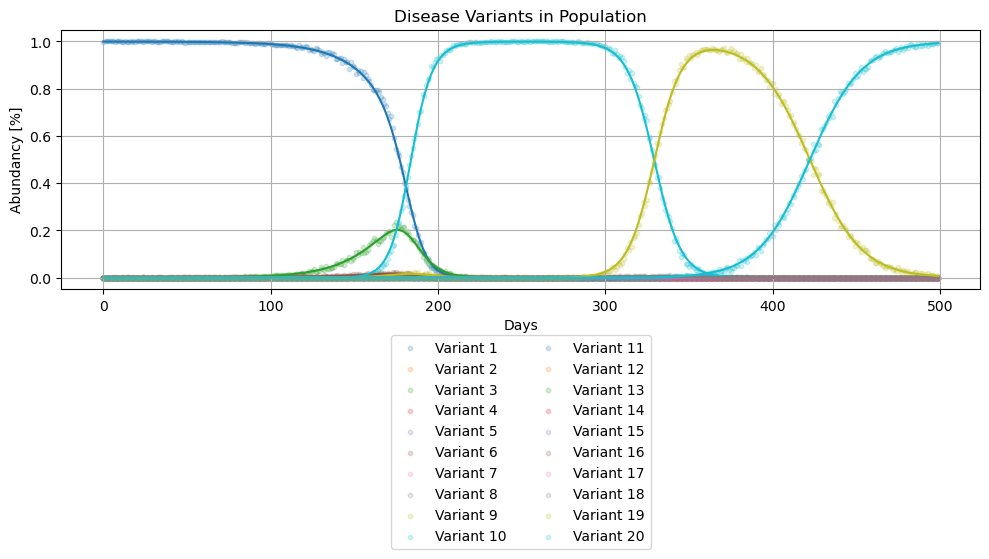

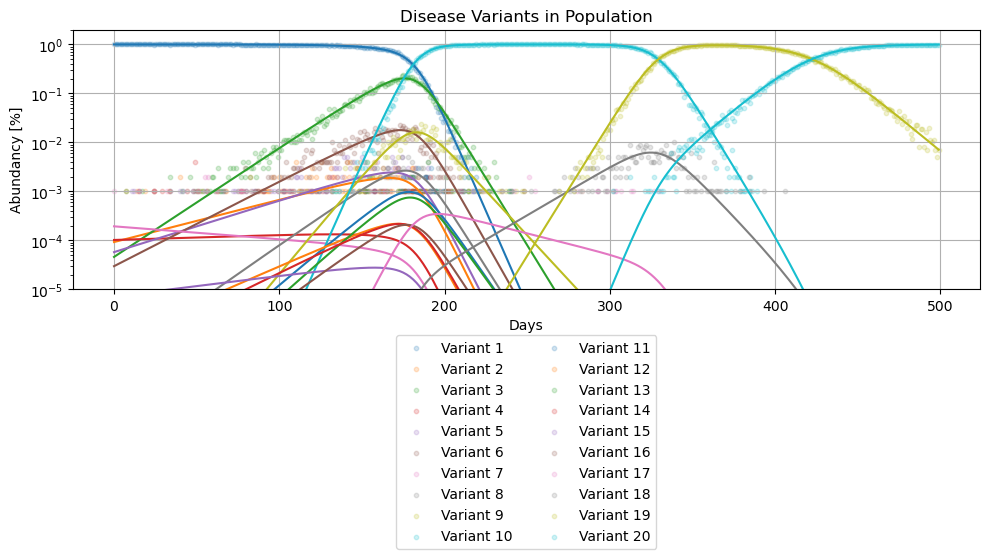

In [9]:
freq_estimate = np.median(posterior.samples['freq'], axis = 0) # now useless since only one value, but collapses axis
freq_estimate = np.hstack((freq_estimate[:, [-1]], freq_estimate[:, :-1]))
counts_estimate = np.median(posterior.samples['seq_counts'], axis = 0)

#composition_estimate = calculate_frequencies(data['counts'].shape[0], s_vec, o_vec) 

plot_viral_composition(data['counts'], freq_estimate, n_samples, logscale = False)
plot_viral_composition(data['counts'], freq_estimate, n_samples, y_range = (1e-5, 2), logscale = True)

In [10]:
o_vec = np.median(posterior.samples['beta'][:,0,:], axis = 0)
o_vec = np.concatenate(([o_vec[-1]], o_vec[:-1]))

s_vec = np.median(posterior.samples['beta'][:,1,:], axis = 0)
s_vec = np.concatenate(([s_vec[-1]], s_vec[:-1]))

hessian_result = calculateHessian(data['counts'], s_vec, o_vec, ignore_pivot = True)

(40,)


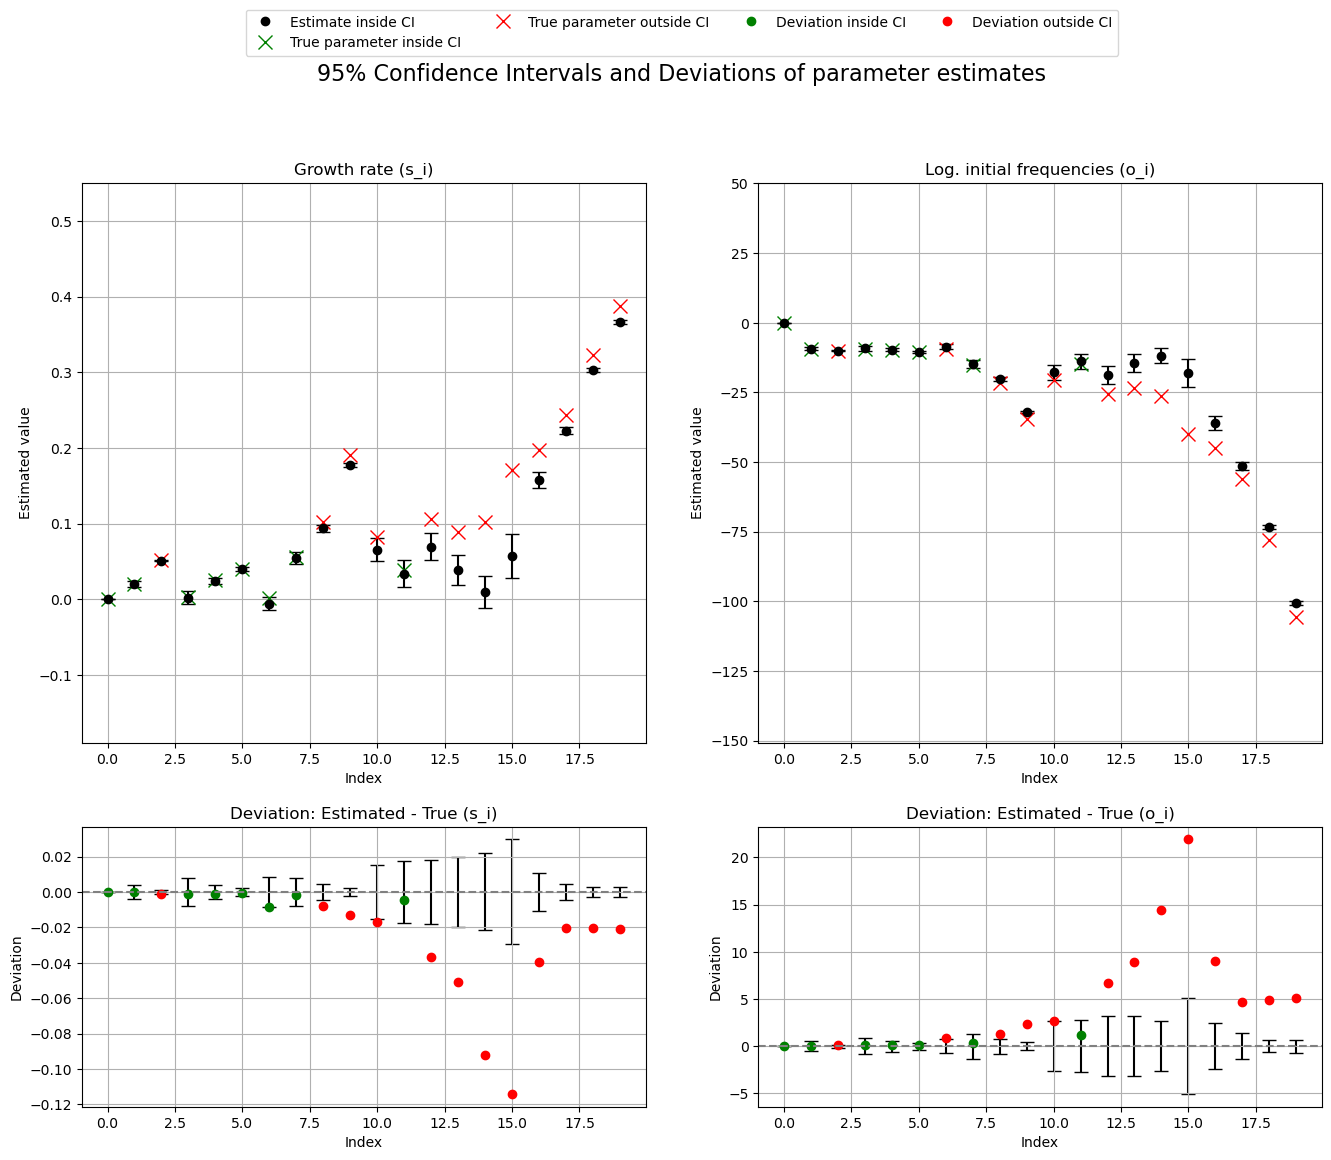

In [25]:
df = evaluate_result(np.concatenate([s_vec, o_vec]), hessian_result['inverse_hessian'], data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals_deviation(df)

## Compare to BFGS optimization

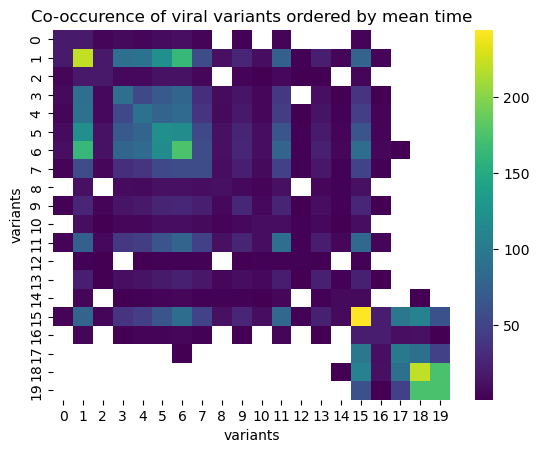

In [12]:
co_occurence_reorderd = calculate_cooccurence(data, reorder=True)
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")

Loop  0
Loop  1


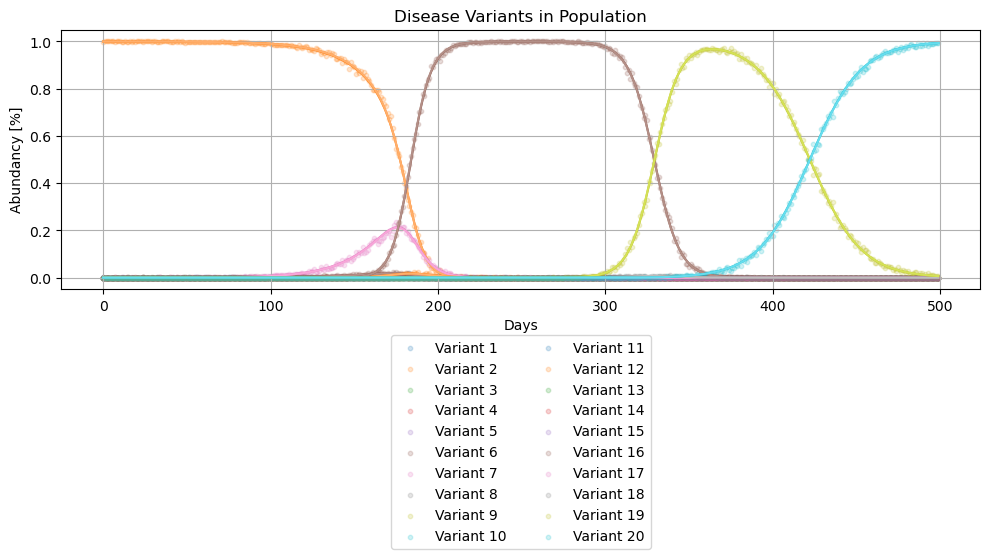

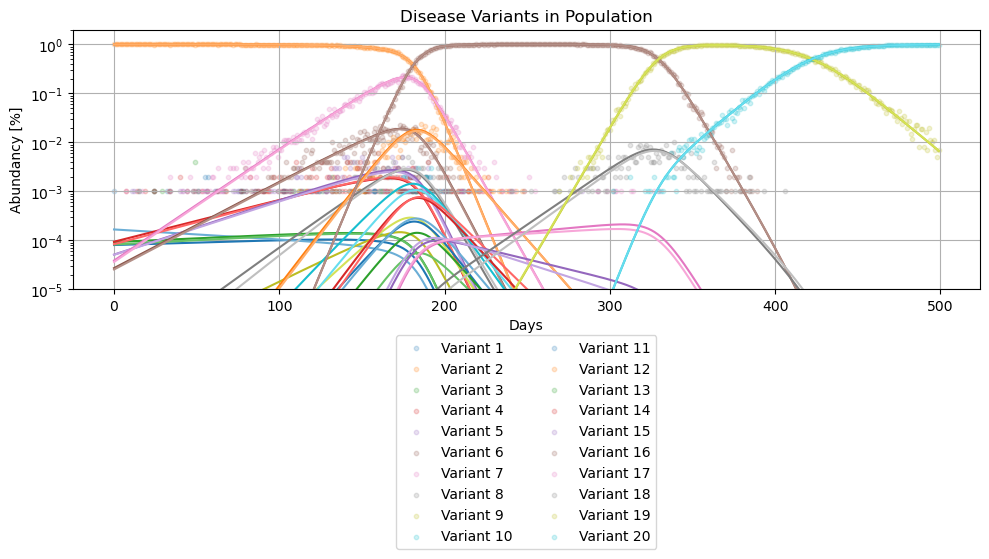

In [13]:
partition_size = 13
overlap_size = 4

result_stepwise = calculate_viral_composition_stepwise(data, partition_size, overlap_size)

plot_viral_composition(result_stepwise['reordered_data']['counts'], result_stepwise['reordered_data']['freq'], n_samples, result_stepwise['composition_estimate'], logscale = False)
plot_viral_composition(result_stepwise['reordered_data']['counts'], result_stepwise['reordered_data']['freq'], n_samples, result_stepwise['composition_estimate'], y_range = (1e-5, 2), logscale = True)

In [14]:
result_stepwise['reordered_data']['growth_rates']

array([0.00232217, 0.        , 0.003542  , 0.01971805, 0.0256228 ,
       0.0406067 , 0.05242355, 0.05609751, 0.03828194, 0.08266749,
       0.08904502, 0.10167935, 0.10165159, 0.10649565, 0.17138586,
       0.19022319, 0.19738303, 0.24327659, 0.32293618, 0.38797818])

(40,)


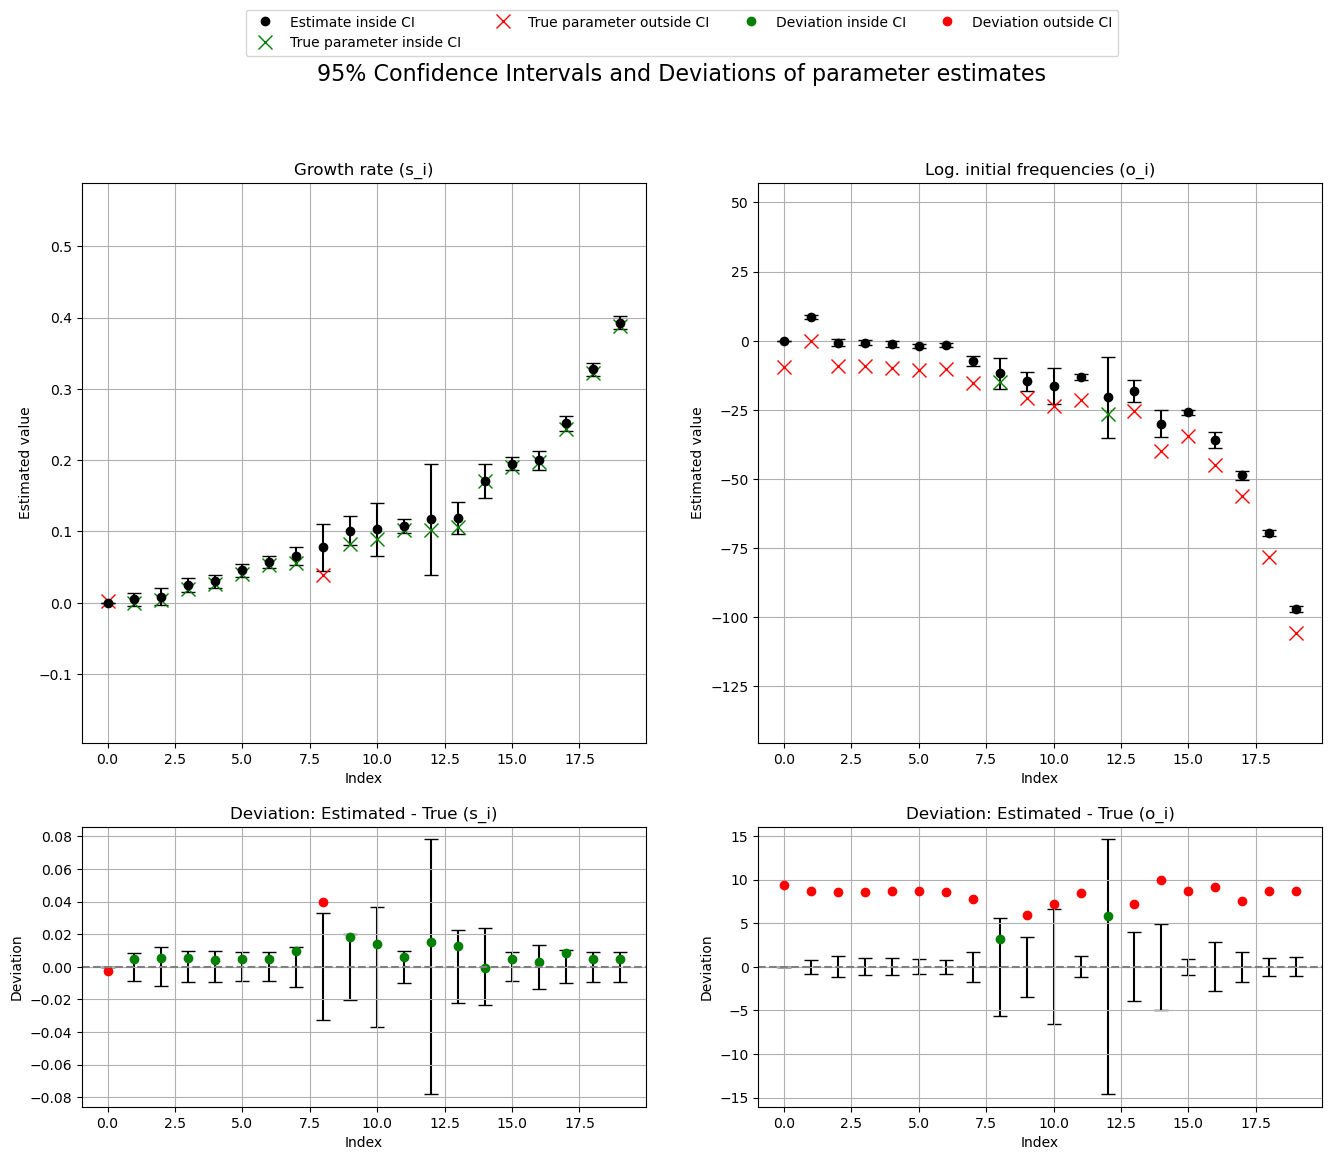

In [15]:
df_bfgs = evaluate_result(np.concatenate([result_stepwise['growth_rate_estimate'], result_stepwise['log_init_freq_estimate']]), np.abs(result_stepwise['hess_inv']), result_stepwise['reordered_data']['growth_rates'], result_stepwise['reordered_data']['log_init_freq'])
plot_confidence_intervals_deviation(df_bfgs)

### Trial with their data

In [19]:
#posterior.save_posterior("data/mlr_estimates.pkl")
# Loading new posterior
#loaded_posterior = ef.PosteriorHandler(data=variant_frequencies).load_posterior("data/mlr_estimates.pkl")

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from evofr.plotting import FrequencyPlot, add_dates_sep

In [21]:
counts_df_test = pd.read_csv("../evofr/test/testing_data/mlr-variant-counts.tsv", sep = "\t")

count_matrix = counts_df_test.pivot_table(
    index='date',
    columns='variant',
    values='sequences',
    aggfunc='sum',
    fill_value=0
)
counts_array = count_matrix.to_numpy()
counts_array.shape

#composition_estimate = calculate_frequencies(counts_array.shape[0], s_vec, o_vec) #maybe log scale


(70, 3)

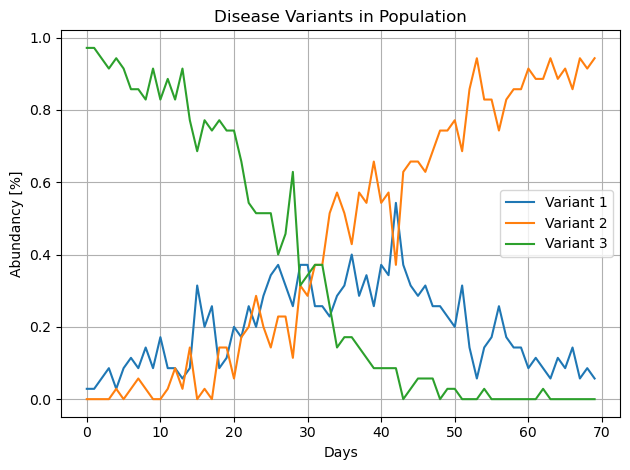

In [22]:
# Plot each variant
def plot_variants(counts):

    day_sums = np.sum(counts, axis = 1)

    for i in range(counts.shape[1]):
        plt.plot(np.arange(counts.shape[0]), counts[:, i] / day_sums[i], label = f'Variant {i+1}') 

    plt.xlabel("Days")
    plt.ylabel("Abundancy [%]")
    plt.title("Disease Variants in Population")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_variants(counts_array)


In [23]:
variant_frequencies = ef.VariantFrequencies(counts_df_test, pivot="variant_0")

mlr = ef.MultinomialLogisticRegression(tau=1) # tau: average generation time (1 day)
#inference_method = ef.InferNUTS(num_samples=1000, num_warmup=1000) # num_warmup defines burn in
inference_method = ef.InferMAP(iters = 10000, lr = 4e-3)


posterior_test = inference_method.fit(mlr, variant_frequencies)

forecast_L = 50
posterior_test.samples = mlr.forecast_frequencies(posterior_test.samples, forecast_L)

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/evofr/data/data_helpers.py:90: UserWarning: variant_0 not present in variant names. Using provided order.
  warnings.warn(f"{pivot} not present in variant names. Using provided order.")


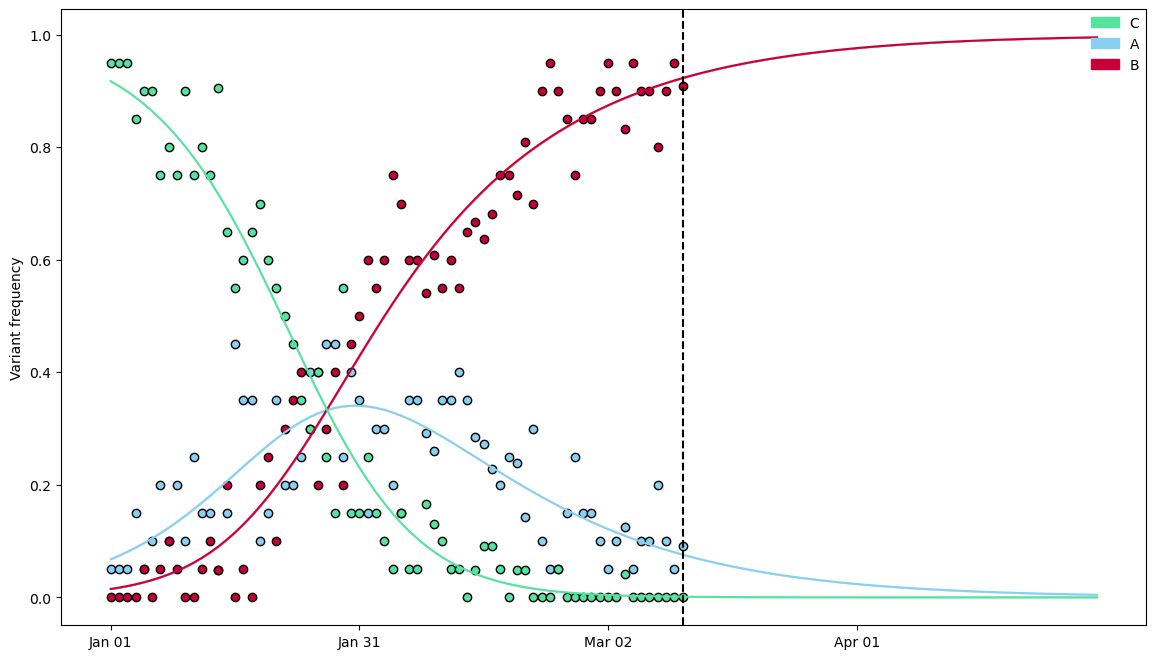

In [24]:
v_colors = ["#56e39f", "#89CFF0", "#C70039"]
v_names = list(counts_df_test.variant.unique())
color_map = {v: c for c, v in zip(v_colors, v_names)}

# Plot predicted frequencies
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(nrows=1, ncols=1)
ax = fig.add_subplot(gs[0,0])

FrequencyPlot(posterior_test, color_map=color_map).plot(ax, forecast=True)
ax.axvline(x=len(variant_frequencies.dates)-1, color='k', linestyle='--') # Adding forecast cut off
add_dates_sep(ax, ef.data.expand_dates(variant_frequencies.dates, forecast_L), sep=30) # Adding dates

ax.legend(
    handles=[
        mpatches.Patch(color=c, label=v) for v, c in color_map.items()
    ],
    loc='upper right',
    fontsize=10,
    frameon=False,
    ncol=1,  # single column
    borderaxespad=0.1
)